# Customer Segmentation using RFM Analysis and KMeans Clustering

## Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


## Load Dataset

In [14]:
import pandas as pd
df = pd.read_csv('/content//part_1_ecommerce_customer_segmentation.csv',
 encoding='latin1')

df.head()

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands


## Data Understanding

In [15]:
df.info ()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4395 entries, 0 to 4394
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4395 non-null   object 
 1   StockCode    4395 non-null   object 
 2   Description  4328 non-null   object 
 3   Category     4395 non-null   object 
 4   Quantity     4395 non-null   int64  
 5   InvoiceDate  4395 non-null   object 
 6   UnitPrice    4395 non-null   float64
 7   CustomerID   4187 non-null   object 
 8   Country      4395 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 309.2+ KB


,Quantity,UnitPrice
count,4395.000000,4395.000000
mean,2.826394,747.081477
std,3.846051,611.134932
min,-50.000000,-2244.520000
25%,1.000000,328.200000
50%,2.000000,544.320000
75%,4.000000,950.470000
max,50.000000,2939.580000


## Data Cleaning

In [16]:
df.dropna(inplace=True)

df = df[df['Quantity'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE,468.04
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE,248.30
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India,3645.60
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands,659.20
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands,526.21


## Exploratory Data Analysis

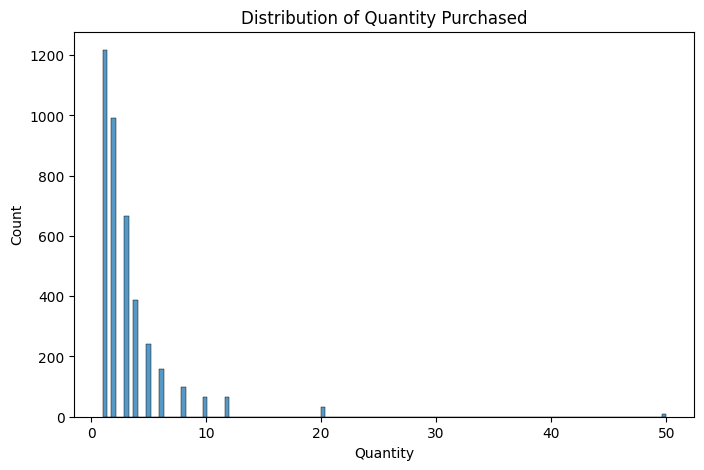

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['Quantity'])

plt.title('Distribution of Quantity Purchased')

plt.xlabel('Quantity')

plt.ylabel('Count')

plt.show()

This chart shows how product quantities are distributed across customer transactions.

## Feature Engineering

In [21]:
today = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': [lambda x: (today - x.max()).days, 'count'],
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
C10001,116,8,22885.81
C10003,32,3,12061.04
C10004,39,7,10579.97
C10005,296,7,14154.57
C10006,30,9,27389.29


RFM metrics help identify customer purchasing behavior based on recency, frequency, and monetary value.

## Model Building / Analysis

In [23]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

kmeans = KMeans(n_clusters = 4, random_state=42)

rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,cluster
CustomerID,,,,
C10001,116,8,22885.81,3
C10003,32,3,12061.04,0
C10004,39,7,10579.97,0
C10005,296,7,14154.57,1
C10006,30,9,27389.29,3


KMeans clustering grouped customer into different segments based on purchasing patterns.

## Evaluation

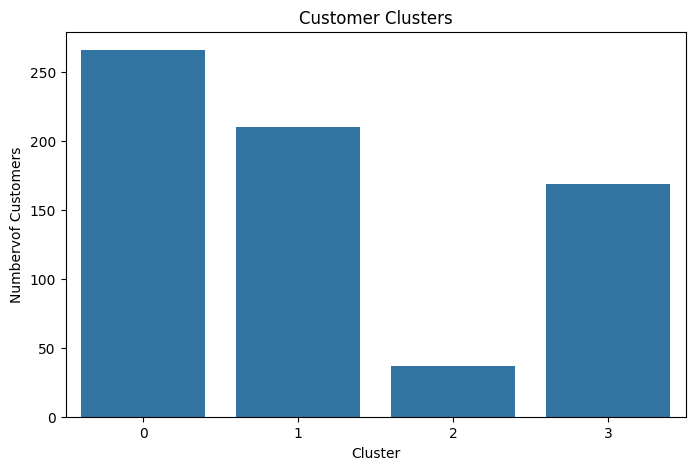

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(x='cluster', data=rfm)

plt.title('Customer Clusters')

plt.xlabel('Cluster')

plt.ylabel('Numbervof Customers')

plt.show()

The graph shows the number of customers present in each cluster group.

## Business Insights

- High-value customers can be targeted using loyalty programs.
- Low-frequency customers may require promotional offers.
- Customer segmentstion improves marketing strategies.

## Final Recommendations

Business should focus on retaining high-valuee customers and improving engagement with inactive customers using targeted campaigns.